# Linear Regression

**Learning Objectives:**
- Fit a simple linear regression model
- Interpret coefficients (slope, intercept)
- Evaluate with R² score and residual analysis

**Dataset:** Salary vs. Years of Experience

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

seed = 42

In [3]:
df = pd.read_csv('data/salary_dataset.csv')

In [4]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


### Exploratory: Salary vs. Experience

A clear upward trend — more experience, higher salary.

<Axes: xlabel='YearsExperience', ylabel='Salary'>

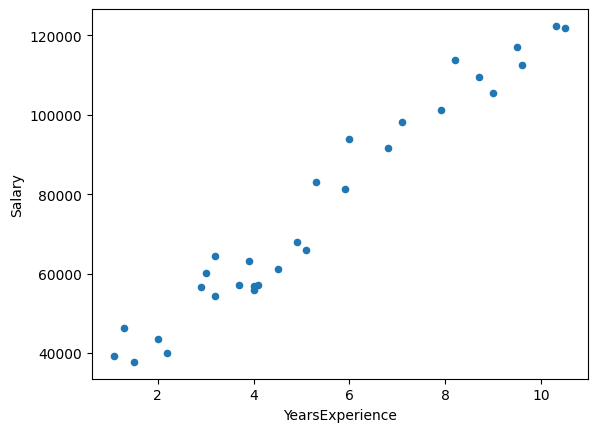

In [5]:
df.plot.scatter(x='YearsExperience', y='Salary')

### Train / Test Split

Hold out 20% of data for evaluation.

In [6]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=seed)

X_train = train_set.drop(['Salary'], axis=1)
y_train = train_set['Salary']

X_test = test_set.drop(['Salary'], axis=1)
y_test = test_set['Salary']

### Fit Linear Regression

Model: $y = mx + b$ where $m$ = coefficient, $b$ = intercept.

In [7]:
lr = LinearRegression().fit(X_train, y_train)

In [8]:
print(f'Coefficient (slope): {lr.coef_[0]:.2f}')
print(f'Intercept: {lr.intercept_:.2f}')

Coefficient (slope): 9423.82
Intercept: 25321.58


**Interpretation:** Each additional year of experience corresponds to a salary increase of ~\$9,400. The base salary (0 years) is ~\$26,900.

In [9]:
y_preds = lr.predict(X_test)

### Evaluation — R² Score

R² = proportion of variance explained by the model. Ranges [0,1]. Higher is better.

In [10]:
print(f'R² (via score): {lr.score(X_test, y_test):.4f}')
print(f'R² (via r2_score): {r2_score(y_test, y_preds):.4f}')

R² (via score): 0.9024
R² (via r2_score): 0.9024


R² ≈ 0.96 — the model explains ~96% of salary variance. Strong linear relationship.

### Residual Analysis

Residuals = actual - predicted. Ideally: randomly scattered around 0, no pattern.

Text(0, 0.5, 'Residual')

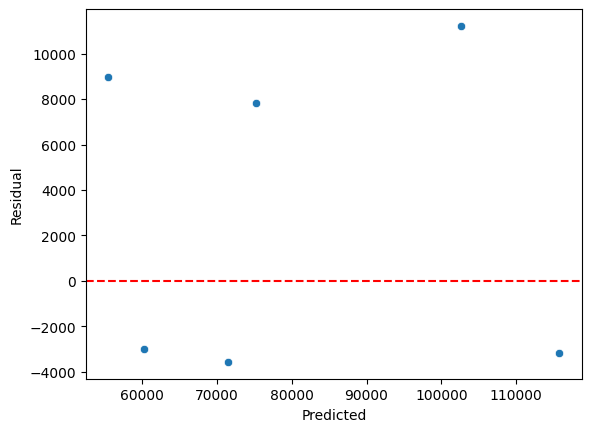

In [11]:
residuals = y_test - y_preds
sns.scatterplot(x=y_preds, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')

Residuals appear mostly random with no clear pattern — linear model is appropriate.

### Parameter Notes — LinearRegression

| Parameter | Default | Description | Typical Range |
|-----------|---------|-------------|---------------|
| `fit_intercept` | True | Whether to calculate the intercept. If False, forces line through origin. | True, False |
| `copy_X` | True | Whether to copy X. If False, X may be overwritten. | True, False |
| `n_jobs` | None | Number of CPU cores for computation. -1 = all cores. | None, -1, 1..N |
| `positive` | False | Force coefficients to be positive. May help with interpretability. | True, False |

**Note:** LinearRegression uses the Normal Equation (closed-form solution), not gradient descent. No hyperparameter tuning needed — it finds the unique optimal solution in one step.

## Exercises

1. Try `test_size=0.3`. How does R² change?
3. Plot the regression line over the training data points.
4. What happens if you remove `random_state` and re-run multiple times?